# Astronomy CNN with uncertainty prediction

In this notebook a CNN is trained to predict:

- temperature (`t_eff`)
- gravity (`log_g`)
- metallicity (`fe_h`)

and also predict a Gaussian uncertainty for each output.

A Gaussian negative log-likelihood (NLL) loss is used.  
The network predicts both the mean and the log standard deviation for each target.

To evaluate if the uncertainty prediction is good, we inspect:

- training and validation loss,
- prediction vs truth scatter plots,
- predicted uncertainty distributions,
- pull distributions `(mu - y) / sigma`.

A well-calibrated uncertainty model should give pull distributions close to a standard normal distribution.

In [1]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
from helper import normalize, denormalize, train_model, get_normalized_data, evaluate_model, denormalize_std
from model_examples import TinyCNN

In [2]:
DATA_PATH = "../data"

learning_rate = 2e-4
batch_size = 32
num_epochs = 50
patience = 10

train_fraction = 0.7
val_fraction = 0.15

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
# Load normalized spectra and labels
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

print("spectra shape:", spectra.shape)
print("labels shape:", labels.shape)
print("spectra length:", spectra_length)
print("n_labels:", n_labels)
print("label names:", labelNames)

spectra shape: (8914, 16384)
labels shape: (8914, 3)
spectra length: 16384
n_labels: 3
label names: ['t_eff', 'log_g', 'fe_h']


In [4]:
# Convert to tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split into train / val / test
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size

dataset = TensorDataset(spectra_tensor, labels_tensor)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"train: {len(train_dataset)}")
print(f"val:   {len(val_dataset)}")
print(f"test:  {len(test_dataset)}")

train: 6239
val:   1337
test:  1338


## Model

The original CNN predicted only the three target values.

Now the network should predict:

- 3 means: `mu`
- 3 log standard deviations: `log_sigma`

So the output dimension becomes `2 * n_labels = 6`.

In [5]:
# Device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


In [6]:
# Model with doubled output size:
# first n_labels entries = means
# last n_labels entries = log_sigmas
model = TinyCNN(2 * n_labels)

summary(model, input_size=(1, spectra_length))
model = model.to(device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 10, 16380]              60
              ReLU-2            [-1, 10, 16380]               0
       BatchNorm1d-3            [-1, 10, 16380]              20
           Dropout-4            [-1, 10, 16380]               0
         AvgPool1d-5             [-1, 10, 5460]               0
            Conv1d-6             [-1, 20, 5456]           1,020
              ReLU-7             [-1, 20, 5456]               0
       BatchNorm1d-8             [-1, 20, 5456]              40
           Dropout-9             [-1, 20, 5456]               0
        AvgPool1d-10             [-1, 20, 1818]               0
           Conv1d-11             [-1, 40, 1814]           4,040
             ReLU-12             [-1, 40, 1814]               0
      BatchNorm1d-13             [-1, 40, 1814]              80
          Dropout-14             [-1, 4

## Gaussian NLL loss

For each target, the model predicts a mean `mu` and a log standard deviation `log_sigma`.

The Gaussian negative log-likelihood (from the lecture) is:

$loss = \frac{1}{N} \sum_i^N \left[ \frac{1}{2}\left(\frac{y_i-\mu_i}{\sigma_i}\right)^2 + \log \sigma_i \right]$

In [7]:
# NLL loss function from the lecture notes
def nll_loss(predictions, batch_labels, n_labels):
    mean = predictions[:, :n_labels]
    log_std = predictions[:, n_labels:]
    std = torch.exp(log_std)
    return torch.mean((0.5 * ((batch_labels - mean) / std) ** 2) + log_std)


In [8]:
def loss_function(inputs, labels, model):
    predictions = model(inputs)
    loss_result = nll_loss(predictions, labels, n_labels)
    return loss_result

In [9]:
# Train the model
train_losses, val_losses, best_model = train_model(
    model,
    train_loader,
    val_loader,
    loss_function,
    learning_rate,
    num_epochs,
    patience,
    device,
    model_name="tiny_CNN_uncertainty"
)

Epoch [1/50], Step [190/195], Loss: -1.3237
Epoch [1/50], Train Loss: -0.9137, Val Loss: -1.3245, Time: 34.28 seconds
Epoch [2/50], Step [190/195], Loss: -1.2082
Epoch [2/50], Train Loss: -1.4150, Val Loss: -1.6491, Time: 32.77 seconds
Epoch [3/50], Step [190/195], Loss: -1.6136
Epoch [3/50], Train Loss: -1.5767, Val Loss: -1.8055, Time: 33.57 seconds
Epoch [4/50], Step [190/195], Loss: -1.8159
Epoch [4/50], Train Loss: -1.6782, Val Loss: -1.8951, Time: 32.78 seconds
Epoch [5/50], Step [190/195], Loss: -1.8030
Epoch [5/50], Train Loss: -1.7436, Val Loss: -1.9125, Time: 37.12 seconds
Epoch [6/50], Step [190/195], Loss: -2.0351
Epoch [6/50], Train Loss: -1.7910, Val Loss: -1.9744, Time: 50.83 seconds
Epoch [7/50], Step [190/195], Loss: -1.8147
Epoch [7/50], Train Loss: -1.8555, Val Loss: -1.9268, Time: 51.17 seconds
Epoch [8/50], Step [190/195], Loss: -2.1316
Epoch [8/50], Train Loss: -1.8690, Val Loss: -2.0568, Time: 32.24 seconds
Epoch [9/50], Step [190/195], Loss: -2.0470
Epoch [9/50]

In [10]:
# Load best model
model.load_state_dict(best_model)
model.to(device)
model.eval()

TinyCNN(
  (model): Sequential(
    (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
    (6): ReLU()
    (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.1, inplace=False)
    (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
    (11): ReLU()
    (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.1, inplace=False)
    (14): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (15): Conv1d(40, 10, kernel_size=(1,), stride=(1,))
    (16): ReLU()
    (17): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (18): Dr

In [11]:
# Evaluate on test set
all_predictions, all_true_labels, _, _ = evaluate_model(model, test_loader, loss_function, device)

# Convert back to torch tensors
all_predictions = torch.tensor(all_predictions, dtype=torch.float32)
all_true_labels = torch.tensor(all_true_labels, dtype=torch.float32)

# Split prediction into mean and log_std
all_mean = all_predictions[:, :n_labels]
all_log_std = all_predictions[:, n_labels:]
all_std = torch.exp(all_log_std)

Evaluating model on the test dataset...
Final Test Loss: -2.2120


In [12]:
all_mean_denorm = denormalize(all_mean, ranges)
all_true_denorm = denormalize(all_true_labels, ranges)
all_std_denorm = denormalize_std(all_std, ranges)

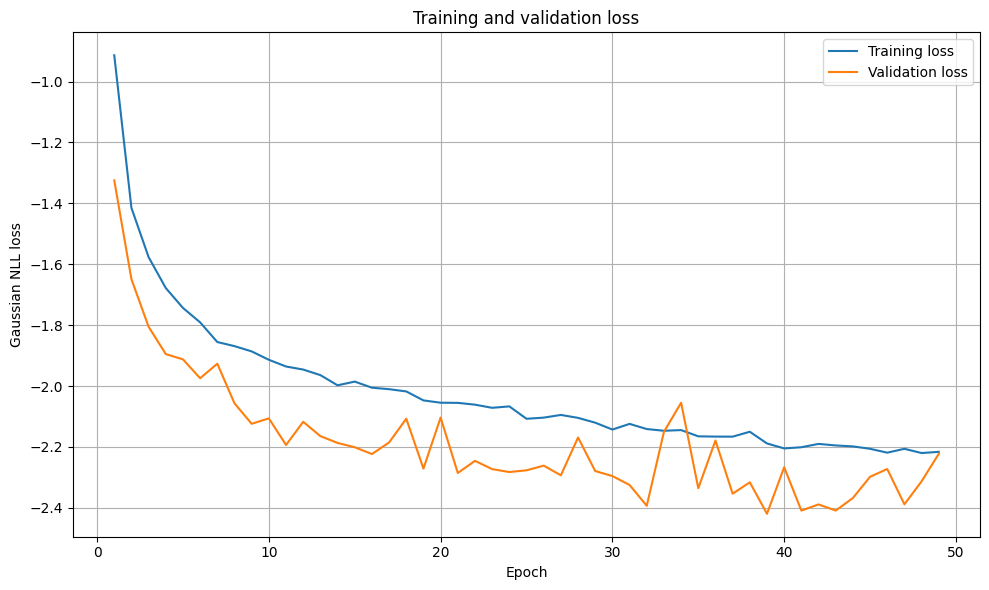

In [ ]:
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/uncertainty_training_validation_loss.png")
plt.show()

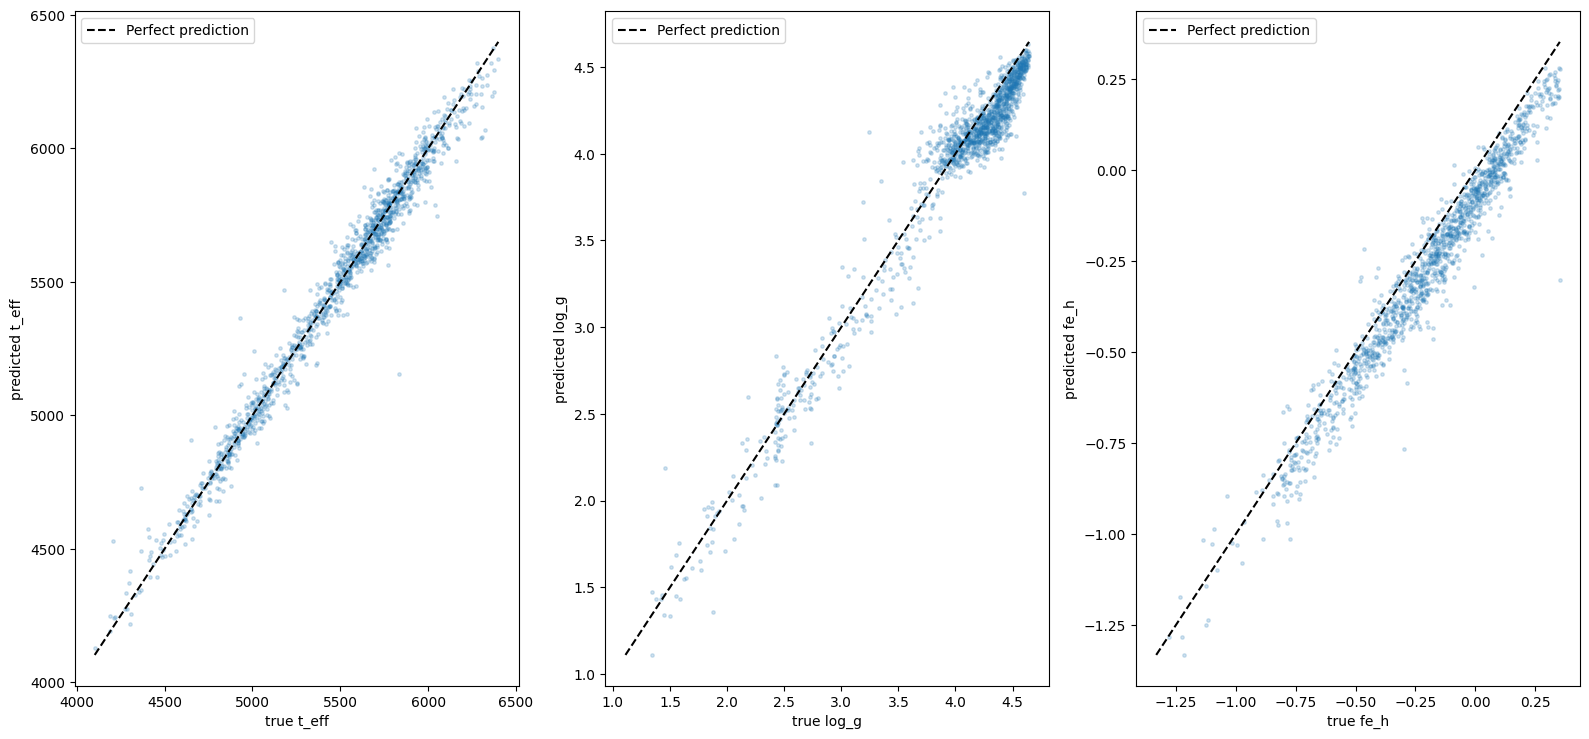

In [14]:
# Scatter plots for predicted means
plt.figure(figsize=(16,7.5))
for j in range(n_labels):
    plt.subplot(1, n_labels, j + 1)
    gt = all_true_denorm[:, j].numpy()
    pred = all_mean_denorm[:, j].numpy()
    plt.scatter(gt, pred, s=6, alpha=0.2)
    mn = min(gt.min(), pred.min())
    mx = max(gt.max(), pred.max())
    plt.plot([mn, mx], [mn, mx], "k--", label="Perfect prediction")
    plt.xlabel(f"true {labelNames[j]}")
    plt.ylabel(f"predicted {labelNames[j]}")
    plt.legend()
plt.tight_layout()
plt.savefig("plots/uncertainty_scatter.png")
plt.show()

## Pull distributions

To evaluate the predicted uncertainties, we use the pull distribution

$
\mathrm{pull} = \frac{\mu - y}{\sigma}
$

where `mu` is the predicted mean, `y` is the true label, and `sigma` is the predicted standard deviation.

For a well-calibrated uncertainty model, the pull distribution should be close to a standard normal distribution with a mean close to 0 and standard deviation close to 1

In [15]:
# Compute pull values in normalized space
pulls = (all_mean - all_true_labels) / all_std

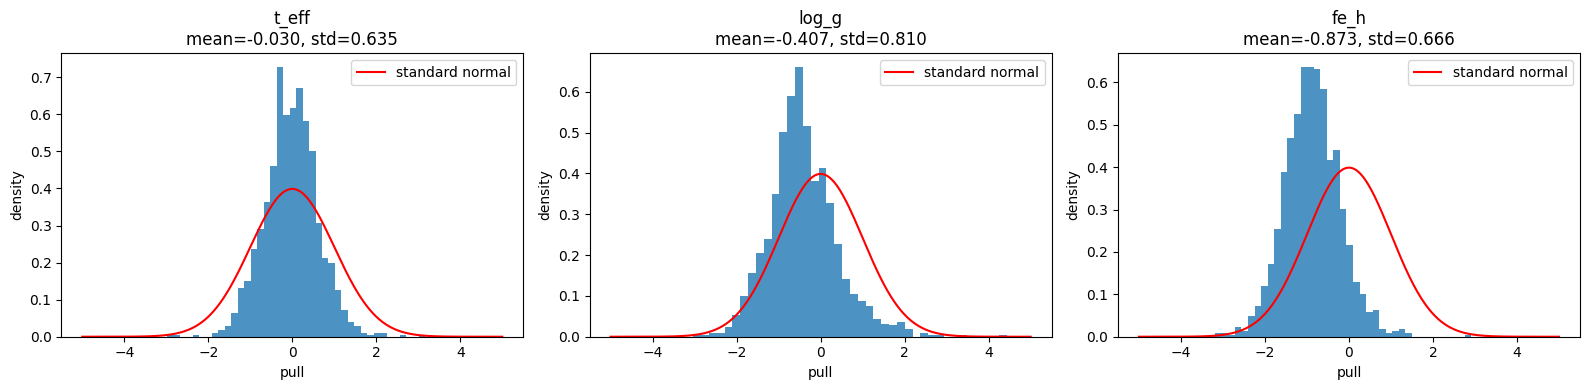

In [16]:
plt.figure(figsize=(16, 4))

for j in range(n_labels):
    plt.subplot(1, n_labels, j + 1)
    p = pulls[:, j].numpy()

    mean_pull = p.mean()
    std_pull = p.std()

    plt.hist(p, bins=40, density=True, alpha=0.8)

    x = np.linspace(-5, 5, 400)
    y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
    plt.plot(x, y, "r-", label="standard normal")

    plt.title(f"{labelNames[j]}\nmean={mean_pull:.3f}, std={std_pull:.3f}")
    plt.xlabel("pull")
    plt.ylabel("density")
    plt.legend()

plt.tight_layout()
plt.savefig("plots/pull_distributions.png")
plt.show()

In [17]:
for j, name in enumerate(labelNames):
    p = pulls[:, j].numpy()
    print(f"{name:>8s} | pull mean: {p.mean():.4f} | pull std: {p.std():.4f}")

   t_eff | pull mean: -0.0296 | pull std: 0.6353
   log_g | pull mean: -0.4074 | pull std: 0.8102
    fe_h | pull mean: -0.8734 | pull std: 0.6664
